In [1]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from dssp import DSSPFile
import requests

%load_ext autoreload 
%autoreload 2

In [2]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 2].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_2.faa')
# subprocess.run('muscle -align ../data/genes/cluster_1.faa -output ../data/genes/cluster_1.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_2 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_2 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_198
orfm.bz_1.1_170
orfm.bz_2.1_13
orfm.bz_3.1_33
orfm.bz_4.1_191
orfm.bz_5.1_157
orfm.bz_7.1_197
orfm.bz_8.1_222
orfm.bz_9.1_15
orfm.bz_10.1_5
orfm.bz_11.1_16

Minimum cluster_2 gene length: 173
Maximum cluster_2 gene length: 196


In [3]:
msa = MSAFile.from_file('../data/genes/cluster_2.afa')
dssp_msa = map_dssp_to_msa(msa, dssp_output_dir='../data/genes/dssp')

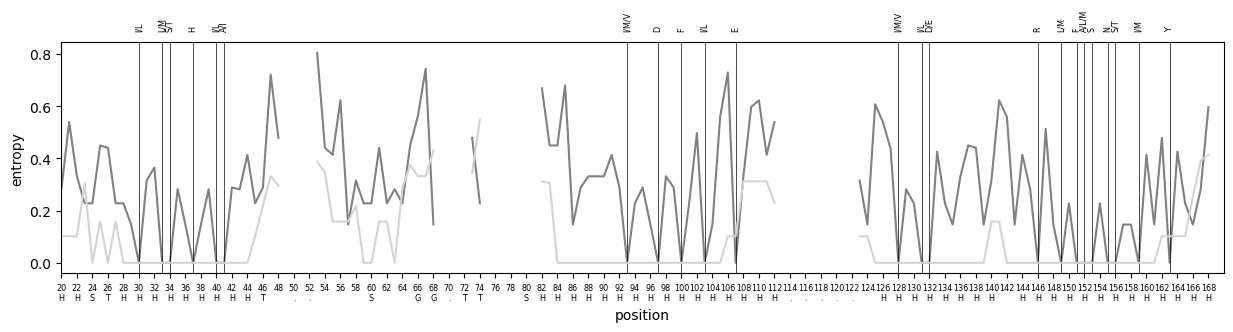

In [4]:
def plot_entropy(msa:MSAFile, max_entropy=0.1, x_min=20, x_max=70, ax:plt.Axes=None, color:str='gray', alphabet:dict=None, annotate:bool=False):

    entropy = msa.get_entropy(alphabet=alphabet, exclude_gaps=True)

    ax.plot(np.arange(len(entropy)), entropy, color=color)

    if annotate:
        conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
        # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
        conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

        for idx, aas in zip(conserved_idxs, conserved_aas):
            if (idx > x_max) or (idx < x_min):
                continue
            ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
            ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 2)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

x_min, x_max = 20, 170
fig, ax = plt.subplots(figsize=(15, 3))

plot_entropy(msa, ax=ax, x_min=x_min, x_max=x_max, alphabet=REDUCED_ALPHABET, annotate=True)
plot_entropy(dssp_msa, ax=ax, color='lightgray', x_min=x_min, x_max=x_max)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]
ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')

plt.show()

# H, D, E, and C are potentially metal-binding. 

In [5]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_2 protein:', row.num_tmhs)

Number TMHs in bz_0 cluster_2 protein: 5
Number TMHs in bz_1 cluster_2 protein: 4
Number TMHs in bz_2 cluster_2 protein: 4
Number TMHs in bz_3 cluster_2 protein: 4
Number TMHs in bz_4 cluster_2 protein: 4
Number TMHs in bz_5 cluster_2 protein: 4
Number TMHs in bz_7 cluster_2 protein: 5
Number TMHs in bz_8 cluster_2 protein: 5
Number TMHs in bz_9 cluster_2 protein: 4
Number TMHs in bz_10 cluster_2 protein: 5
Number TMHs in bz_11 cluster_2 protein: 5


In [ ]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]


# target_header_map = dict()
# foldseek_search_df['target_header'] = foldseek_search_df.target_header.apply(lambda header : target_header_map.get(header, header))

In [8]:
filters = dict()
filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['synthetic'] = foldseek_search_df.target_header.str.contains('Computationally designed|synthetic|de novo|De novo|Engineered')

# foldseek_search_df = apply_filters(filters, foldseek_search_df)

apply_filters(filters, foldseek_search_df).sort_values('alignment_tm_score')[['target_header', 'alignment_tm_score', 'query_start', 'query_end']].iloc[-50:]


apply_filters: 18833 entries removed by low_tm_score.
apply_filters: 3 entries removed by short_alignment.
apply_filters: 119 entries removed by synthetic.


,target_header,alignment_tm_score,query_start,query_end
38896,8hj0-assembly1_R GPR21(m5) and G15 complex,0.7495,62,147
5303,5me8-assembly1_B N-terminal domain of the huma...,0.7496,72,128
4446,B2ZYL0,0.7498,69,147
26742,A0A6B9USC0,0.7503,74,130
22874,A0A385EE06,0.7503,63,116
28563,A0A4Y1NT44,0.7510,59,115
22896,A0A8E5K783,0.7514,62,119
23551,5dxh-assembly2_E p110alpha/p85alpha with compo...,0.7518,73,130
4534,A0A516M8M6,0.7525,69,132
8462,AF-A0A127A5X3-F1-model_v6 DNA-binding protein,0.7534,75,131


In [ ]:
# ALPHAFOLD_ACCESSION_PATTERN = r'[A-Z0-9]+$'
# ALPHAFOLD_METADATA_PATH = '../data/genes/cluster_2_alphafold_metadata.tsv'
# foldseek_search_targets_missing_annotation = foldseek_search_df[foldseek_search_df.theader.str.match(ALPHAFOLD_ACCESSION_PATTERN)].theader.values 
# foldseek_search_targets_missing_annotation = np.unique(foldseek_search_targets_missing_annotation)

# print('Number of targets missing an annotation:', len(foldseek_search_targets_missing_annotation))

# if not os.path.exists(ALPHAFOLD_METADATA_PATH):
#     alphafold_metadata_df = list()
#     for accession in tqdm(foldseek_search_targets_missing_annotation, desc='Obtaining additional annotation information from AlphaFold.'):
#         url = f'https://alphafold.ebi.ac.uk/api/prediction/{accession}'
#         result = requests.get(url).text
#         if result == 'error':
#             continue
#         alphafold_metadata_df += json.loads(result)

#     alphafold_metadata_df = pd.DataFrame(alphafold_metadata_df).set_index('uniprotAccession')
#     alphafold_metadata_df.to_csv(ALPHAFOLD_METADATA_PATH)

# else:
#     alphafold_metadata_df = pd.read_csv(ALPHAFOLD_METADATA_PATH, index_col=0)

# UNCHARACTERIZED_PROTEIN_PATTERN = list()
# UNCHARACTERIZED_PROTEIN_PATTERN += ['putative membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane domain-containing protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['putative phage protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized phage protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized PPE family protein PPE1']

# alphafold_metadata_df['uniprotDescription'] = alphafold_metadata_df.uniprotDescription.fillna('Uncharacterized protein')
# alphafold_metadata_df.loc['A0A8S5UYN7_2', 'uniprotDescription'] = 'Endosialidase chaperone'
# alphafold_metadata_df.loc['A0A481Z8K0_1', 'uniprotDescription'] = 'DNA-directed RNA polymerase'
# alphafold_metadata_df.loc['A0A8S5LUT4_2', 'uniprotDescription'] = 'Tail protein'
# alphafold_metadata_df.loc['UPI00200D28BD', 'uniprotDescription'] = 'Uncharacterized protein'
# alphafold_metadata_df['uncharacterized'] = alphafold_metadata_df.uniprotDescription.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

# print('Number of additional retrieved annotations:', (~alphafold_metadata_df.uncharacterized).sum())

# annotations = alphafold_metadata_df.uniprotDescription.to_dict()
# foldseek_search_df['theader'] = foldseek_search_df.theader.apply(lambda theader : annotations.get(theader, theader))
# foldseek_search_df['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

Number of targets missing an annotation: 2311
Number of additional retrieved annotations: 614


In [ ]:
filters = dict()
filters['large_e_value'] = foldseek_search_df.evalue > 0.5
filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.5
filters['eukaryotic'] = foldseek_search_df.taxlineage.str.contains('Eukaryota') | foldseek_search_df.theader.str.contains('human')
filters['low_query_coverage'] = foldseek_search_df.qcov < 0.5
filters['low_target_coverage'] = foldseek_search_df.tcov < 0.5
filters['synthetic'] = foldseek_search_df.theader.str.contains('Computationally designed|synthetic|de novo|De novo')
filters['target_too_long'] = foldseek_search_df.tlen > 300 
filters['no_transmembrane_helix'] = ~foldseek_search_df.target_has_tmh
filters['fragment'] = foldseek_search_df.theader.str.contains('fragment', case=False)

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')
print()

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of filtered Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

print('\nNumber of Foldseek hits after filtering:', len(foldseek_search_df))
print('Number of unique Foldseek hits after filtering:', foldseek_search_df.target.nunique())

apply_filters: 6 entries removed by large_e_value.
apply_filters: 11312 entries removed by low_tm_score.
apply_filters: 6514 entries removed by eukaryotic.
apply_filters: 1541 entries removed by low_query_coverage.
apply_filters: 5870 entries removed by low_target_coverage.
apply_filters: 85 entries removed by synthetic.
apply_filters: 8265 entries removed by target_too_long.
apply_filters: 10878 entries removed by no_transmembrane_helix.
apply_filters: 602 entries removed by fragment.

Number of filtered Foldseek hits for orfm.bz_0.1_198: 51 	bfvd (34) alphafold_swissprot (7) pdb (5) alphafold_uniprot (5)
Number of filtered Foldseek hits for orfm.bz_1.1_170: 106 	bfvd (46) alphafold_swissprot (31) alphafold_uniprot (20) pdb (9)
Number of filtered Foldseek hits for orfm.bz_10.1_5: 6 	alphafold_uniprot (3) bfvd (2) alphafold_swissprot (1)
Number of filtered Foldseek hits for orfm.bz_11.1_16: 87 	alphafold_uniprot (48) bfvd (24) alphafold_swissprot (12) pdb (3)
Number of filtered Foldsee

In [ ]:
UNCHARACTERIZED_PROTEIN_PATTERN += ['UPF0316 protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['TMhelix containing protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['pentapeptide repeat protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized conserved protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane domain protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['polyprotein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['conserved lipothrixviral protein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['polyprotein']
UNCHARACTERIZED_PROTEIN_PATTERN += ['polyprotein']


foldseek_search_categories = dict()


foldseek_search_categories['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

foldseek_search_categories['phage tail'] = foldseek_search_df.theader.str.contains('phage tail', case=False)
foldseek_search_categories['holin'] = foldseek_search_df.theader.str.contains('holin', case=False)
foldseek_search_categories['internal virion'] = foldseek_search_df.theader.str.contains('internal virion', case=False)
foldseek_search_categories['integrin'] = foldseek_search_df.theader.str.contains('alpha 3 protein|LemA', case=False)
foldseek_search_categories['viral envelope protein'] = foldseek_search_df.theader.str.contains('p74-like protein|interleukin|Nsp2TF')
foldseek_search_categories['membrane integrity protein'] = foldseek_search_df.theader.str.contains('YtaF|YciB')
foldseek_search_categories['membrane-bound transcription factor'] = foldseek_search_df.theader.str.contains('BcrR|zinc ribbon', case=False)
foldseek_search_categories['membrane-bound quinol-associated protein'] = foldseek_search_df.theader.str.contains('fumarate reductase subunit D|quinol oxidase|cytochrome', case=False)

foldseek_search_categories['receptor'] = foldseek_search_df.theader.str.contains('GPCR|receptor|Apo')

foldseek_search_categories['sugar phosphate exchanger'] = foldseek_search_df.theader.str.contains('glucose-6-phosphate exchanger|sugar phosphate exchanger', case=False)
# 
foldseek_search_categories['ATP synthase subunit'] = foldseek_search_df.theader.str.contains('ATP synthase|ATPase protein 9|ATPase') # Forms a "c-ring" of 8+ copies of subunit c. Nothing passes through it, but it rotates

foldseek_search_categories['DUF* domain-containing protein'] = foldseek_search_df.theader.str.contains('DUF', case=True)

# foldseek_search_categories['ExbB biopolymer transporter'] = foldseek_search_df.theader.str.contains('ExbD') # The ExbD/ExcB complex hit is to the ExbB protein. It is not an ion transporter, it probably moves protons. It forms a pentameric pore with conserved polar residues.
foldseek_search_categories['membrane synthesis protein'] = foldseek_search_df.theader.str.contains('phosphatidate cytidylyltransferase|DgkA|undecaprenyl-diphosphatase|glycoprotein', case=False)

foldseek_search_categories['MotA/ExbB-like proton channel'] = foldseek_search_df.theader.str.contains('MotA|ExbB|TolQR') # These all form pentamers!
foldseek_search_categories['CorA magnesium transporter'] = foldseek_search_df.theader.str.contains('CorA')
foldseek_search_categories['MdtI/J spermidine transporter'] = foldseek_search_df.theader.str.contains('MdtI|MdtJ')
foldseek_search_categories['MntP manganese efflux pump'] = foldseek_search_df.theader.str.contains('MntP')
foldseek_search_categories['ClR chloride pump'] = foldseek_search_df.theader.str.contains('ClR')
foldseek_search_categories['RcnA nickel/cobalt efflux'] = foldseek_search_df.theader.str.contains('RcnA')
foldseek_search_categories['LarQ nickel permease'] = foldseek_search_df.theader.str.contains('LarQ')
foldseek_search_categories['membrane effector'] = foldseek_search_df.theader.str.contains('PtPycTM')# PtPycTM oligomerizes when a toxin is detected.

foldseek_search_categories['pore-forming toxin'] = foldseek_search_df.theader.str.contains('AhlC|cytolysin A pore')
foldseek_search_categories['pore component'] = foldseek_search_df.theader.str.contains('Mce1-LucB complex')

foldseek_search_categories['TrbJ conjugal transfer protein'] = foldseek_search_df.theader.str.contains('TrbJ')

foldseek_search_categories['Nuok-like protein'] = foldseek_search_df.theader.str.contains('NADH-quinone oxidoreductase subunit K') # Not a transporter

foldseek_search_categories['type IV secretion system'] = foldseek_search_df.theader.str.contains('VirB5|PtlA|VirB6')
foldseek_search_categories['membrane stress response'] = foldseek_search_df.theader.str.contains('HdeD')
foldseek_search_categories['amino acid transporter'] = foldseek_search_df.theader.str.contains('amino-acid transporter|leucine efflux|arginine exporter', case=False)
foldseek_search_categories['miscellaneous transporter'] = foldseek_search_df.theader.str.contains('guanidinium exporter|multidrug transporter|multidrug resistance|mmr|PduT|SugE', case=False)

foldseek_search_categories = list(zip(*list(foldseek_search_categories.items())))
foldseek_search_df['category'] = np.select(condlist=foldseek_search_categories[-1], choicelist=foldseek_search_categories[0], default='none')

# The type IV secretion system protein hits (PtlA and BirB6) are interesting, as they are associated with ring-shaped ATPases
# These proteins probably do not form homo-multimeric pores, but associate with other T4SS proteins. This raises the possibility that cluster_2 interacts with something
# other than the ATPase. 

foldseek_search_df[foldseek_search_df.category == 'none'].theader.value_counts()
foldseek_search_df[(foldseek_search_df.category == 'none')].theader.tolist()
foldseek_search_df[(foldseek_search_df.category != 'uncharacterized')].sort_values(['prob'], ascending=False)[['prob', 'alntmscore', 'qcov', 'tcov', 'theader', 'category']].iloc[:50]
# foldseek_search_df[foldseek_search_df.category.str.contains('type IV')].sort_values(['alntmscore'], ascending=False)[['alntmscore', 'qcov', 'tcov', 'theader', 'category']].theader.tolist()

,prob,alntmscore,qcov,tcov,theader,category
11413,0.537,0.5755,0.972,0.948,5g2c-assembly1_A The crystal structure of ligh...,ClR chloride pump
113223,0.473,0.7086,0.708,0.949,5sv0-assembly2_J Structure of the ExbB/ExbD co...,MotA/ExbB-like proton channel
11414,0.473,0.5611,0.967,0.989,5g2d-assembly1_A The crystal structure of ligh...,ClR chloride pump
71276,0.382,0.6333,0.768,0.693,AF-B2RZW9-F1-model_v6 Undecaprenyl-diphosphatase,membrane synthesis protein
71277,0.353,0.6255,0.763,0.688,AF-O51273-F1-model_v6 Undecaprenyl-diphosphatase,membrane synthesis protein
11417,0.353,0.5659,0.945,0.705,8cqd-assembly1_B Cryo-EM structure of hexameri...,none
153963,0.326,0.5116,0.983,0.703,Baculoviridae p74-like protein,viral envelope protein
153940,0.301,0.6673,0.665,0.930,Holin,holin
80909,0.277,0.6191,0.985,0.789,Holin,holin
67123,0.277,0.6186,0.983,0.948,Glycoprotein,membrane synthesis protein


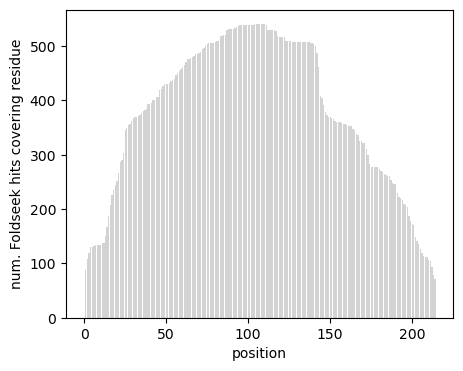

In [ ]:
plot_foldseek_search_coverage(msa, foldseek_search_df=foldseek_search_df)

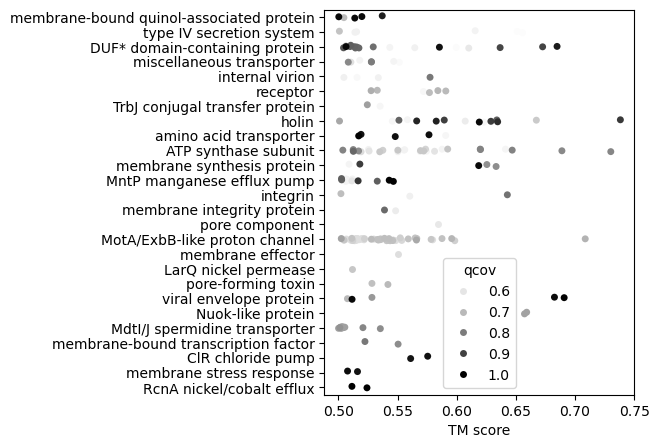

In [ ]:
fig, ax = plt.subplots(figsize=(4, 5))

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()

figure_df = figure_df.sort_values('qcov')
sns.stripplot(figure_df, x='alntmscore', y='category', hue='qcov', palette='Grays')
ax.set_ylabel('')
ax.set_xlabel('TM score')
plt.show()

In [ ]:
print(foldseek_search_df.sort_values('alntmscore', ascending=False)[['theader', 'alntmscore', 'qcov', 'tcov']].theader.tolist())
# 8yy1-assembly1_Z Vo domain of V/A-ATPase from Thermus thermophilus state3
# ATPase protein 9
# Q6MLJ0
# DUF4105 Domain found in putative membrane proteins in bacteria and archaea.
# Transmembrane protein 196 is human.
# T4 recombination mediator protein UvsY is not transmembrane.
# 5jsn-assembly2_D Bcl2-inhibitor complex is human.

foldseek_search_df.sort_values('alntmscore', ascending=False)[['theader', 'alntmscore', 'qcov', 'tcov']].iloc[:30]
print('\n'.join(foldseek_search_df[foldseek_search_df.category == 'ATP synthase subunit'].theader))

['Holin', 'AF-B1AIC5-F1-model_v6 ATP synthase subunit c', 'Uncharacterized protein', 'Uncharacterized protein', '5sv0-assembly2_J Structure of the ExbB/ExbD complex from E. coli at pH 7.0', 'Uncharacterized protein', 'Uncharacterized protein', 'Nsp2TF protein', '8yy1-assembly1_Z Vo domain of V/A-ATPase from Thermus thermophilus state3', 'Putative membrane protein', 'AF-A0A7Z9Z8W0-F1-model_v6 DUF308 domain-containing protein', 'Nsp2TF protein', 'Uncharacterized protein', 'Uncharacterized protein', 'Uncharacterized protein', 'Uncharacterized protein', 'Membrane protein A31', 'Uncharacterized protein', 'AF-A0A4R9AJ38-F1-model_v6 DUF4233 domain-containing protein', 'Holin', 'Uncharacterized protein', 'Uncharacterized protein', 'Uncharacterized protein', '7wem-assembly1_A Solid-state NMR Structure of TFo c-Subunit Ring', 'AF-P71041-F1-model_v6 Uncharacterized protein YwnF', 'Uncharacterized protein', 'AF-B0TWQ4-F1-model_v6 NADH-quinone oxidoreductase subunit K', 'Uncharacterized protein', '

In [ ]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'
COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
COLABFOLD_PLDDTS = dict()

for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):    
    if get_gene_id(path) not in genes_df.index.values: 
        continue 

    with open(path, 'r') as f:
        scores = json.load(f)
        plddts = np.array(scores['plddt'])
        COLABFOLD_PLDDTS[get_gene_id(path)] = plddts

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}
# fig, ax = plt.subplots(figsize=(10, 3.5))
# for gene_id, plddts in COLABFOLD_PLDDTS.items():
#     ax.plot(np.arange(len(plddts)), plddts, label=gene_id, color=palette[gene_id])
# ax.set_xlim(xmin=0, xmax=180)
# ax.set_ylabel('pLDDT')
# ax.set_xlabel('position')
# plt.show()

pattern = '(' + '|'.join(genes_df.index) + ')' + r'_relaxed_rank_001_alphafold2_ptm_model_\d_seed_\d\d\d\.pdb'
paths = [path for path in glob.glob(os.path.join(COLABFOLD_DIR, '**', '*')) if (re.search(pattern, path) is not None)]
for path in paths:
    output_path = os.path.join('/home/prichter/Documents/banfield/betazoid/data/genes/metal3d/', f'{get_gene_id(path)}')
    cmd = f'metal3d --pdb {os.path.abspath(path)} --metalbinding --writeprobes --probefile {output_path}.pdb --maxp --writecube --cubefile {output_path}.cube --softext'
    print(cmd)

metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_0/orfm.bz_0.1_198_relaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb --metalbinding --writeprobes --probefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_0.1_198.pdb --maxp --writecube --cubefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_0.1_198.cube --softext
metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_5/orfm.bz_5.1_157_relaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb --metalbinding --writeprobes --probefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_5.1_157.pdb --maxp --writecube --cubefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_5.1_157.cube --softext
metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_1/orfm.bz_1.1_170_relaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb --metalbinding --writeprobes --probefile /home/prich

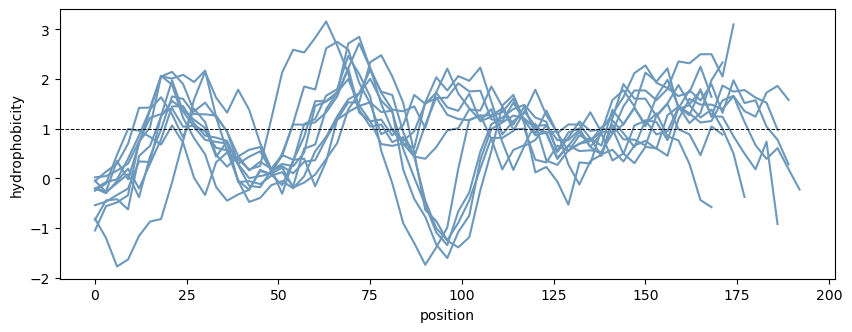

In [ ]:
HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

window_size = 20
step_size = 3

cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

fig, ax = plt.subplots(figsize=(10, 3.5))
for row in genes_df.itertuples():
    window_starts = list(range(0, len(row.seq), step_size))[:-1]
    windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]
    hydrophobicity = [get_hydrophobicity(window) for window in windows]
    ax.plot(window_starts, hydrophobicity, label=gene_id, color=palette[gene_id])

ax.set_ylabel('hydrophobicity')
ax.set_xlabel('position')
ax.axhline(1, ls='--', color='black', lw=0.7)
plt.show()